<a href="https://colab.research.google.com/github/p06735/PIDM/blob/main/PokemonTCG_DF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import ast
import re

In [ ]:
# Carregar os dados
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/pokemondata/pokemon-tcg-data-master 1999-2023.csv')

cols = [
    'id', 'generation', 'release_date', 'types', 'supertype',
    'subtypes', 'level', 'hp', 'abilities', 'attacks',
    'weaknesses', 'rarity', 'nationalPokedexNumbers',
    'resistances'
]
df = df[cols].copy()

print(f"Formato inicial (todas as cartas): {df.shape}")

# Excluir cartas que não sejam Pokémon (Energias, Itens/Treinadores) para uma análise mais apurada
df['supertype'] = df['supertype'].astype(str).str.strip()
df = df[df['supertype'].str.lower().isin(['pokémon', 'pokemon'])].copy()
df = df.reset_index(drop=True)

print(f"Formato após remover Energias/Treinadores (apenas Pokémon): {df.shape}")

# =========================================================================
# CORREÇÃO DA COLUNA 'generation'
# O dataset bruto traz 11 valores distintos em 'generation', embora o jogo
# tenha oficialmente apenas 9 gerações. Isso acontece por dois motivos:
#
# 1) 'Fourth' aparece duplicada como 'Fourth' e 'Fourth ' (com espaço extra
#    no final), sendo tratadas como categorias diferentes pelo pandas mesmo
#    representando a mesma 4ª geração (Sinnoh, 2007-2011).
#    -> Corrigido com .str.strip() para remover espaços em branco.
#
# 2) Existe o valor 'Other', que não é uma geração do jogo principal, e sim
#    uma categoria para produtos avulsos/promocionais sem geração associada
#    (ex.: Pokémon Rumble, coleções promocionais do McDonald's, Pokémon
#    Futsal Collection).
#    -> Removido do dataset, pois não corresponde a nenhuma geração oficial.
# =========================================================================

print(f"\nValores de 'generation' ANTES da correção ({df['generation'].nunique()} únicos):")
print(sorted(df['generation'].unique(), key=str))

# 1) Remover espaços em branco (corrige a duplicação 'Fourth' / 'Fourth ')
df['generation'] = df['generation'].astype(str).str.strip()

# 2) Remover cartas cuja geração é 'Other' (produtos sem geração oficial)
qtd_other = (df['generation'] == 'Other').sum()
df = df[df['generation'] != 'Other'].copy()
df = df.reset_index(drop=True)

print(f"\nRemovidas {qtd_other} cartas com generation == 'Other' (produtos promocionais/avulsos).")
print(f"Valores de 'generation' APÓS a correção ({df['generation'].nunique()} únicos):")
print(sorted(df['generation'].unique(), key=str))
print(f"\nFormato após correção de gerações: {df.shape}")


Mounted at /content/drive
Formato inicial (todas as cartas): (17172, 14)
Formato após remover Energias/Treinadores (apenas Pokémon): (14497, 14)

Valores de 'generation' ANTES da correção (11 únicos):
['Eighth', 'Fifth', 'First', 'Fourth', 'Fourth ', 'Ninth', 'Other', 'Second', 'Seventh', 'Sixth', 'Third']

Removidas 157 cartas com generation == 'Other' (produtos promocionais/avulsos).
Valores de 'generation' APÓS a correção (9 únicos):
['Eighth', 'Fifth', 'First', 'Fourth', 'Ninth', 'Second', 'Seventh', 'Sixth', 'Third']

Formato após correção de gerações: (14340, 14)


In [ ]:
# Extração de variáveis numéricas diretas (data, nível, HP, pokedex)

# Data de lançamento -> Ano
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

# HP -> Converter para numérico e preencher eventuais nulos com a mediana dos pokémon
df['hp'] = pd.to_numeric(df['hp'], errors='coerce')
df['hp'] = df['hp'].fillna(df['hp'].median())

# Nível -> Extrair apenas os dígitos e converter para numérico
def extract_number(val):
    if pd.isna(val) or val == 'Desconhecido':
        return 0
    nums = re.findall(r'\d+', str(val))
    return int(nums[0]) if nums else 0

df['level_num'] = df['level'].apply(extract_number)

# National Pokedex -> Extrair primeiro número da lista
def extract_pokedex(val):
    if pd.isna(val):
        return 0
    try:
        lst = ast.literal_eval(val)
        if isinstance(lst, list) and len(lst) > 0:
            return int(lst[0])
        return 0
    except:
        return 0

df['pokedex_num'] = df['nationalPokedexNumbers'].apply(extract_pokedex)

In [ ]:
# Limpeza de listas e dicionários para extrair o texto principal

def extract_first_string(val):
    if pd.isna(val):
        return 'Desconhecido'
    try:
        lst = ast.literal_eval(val)
        if isinstance(lst, list) and len(lst) > 0:
            return str(lst[0])
        return str(val)
    except:
        return str(val)

def extract_dict_name(val, key='name'):
    if pd.isna(val):
        return 'Desconhecido'
    try:
        lst = ast.literal_eval(val)
        if isinstance(lst, list) and len(lst) > 0 and isinstance(lst[0], dict):
            return str(lst[0].get(key, 'Desconhecido'))
        return str(val)
    except:
        return str(val)

df['types_clean'] = df['types'].apply(extract_first_string)
df['subtypes_clean'] = df['subtypes'].apply(extract_first_string)
df['abilities_clean'] = df['abilities'].apply(lambda x: extract_dict_name(x, 'name'))
df['attacks_clean'] = df['attacks'].apply(lambda x: extract_dict_name(x, 'name'))
df['weaknesses_clean'] = df['weaknesses'].apply(lambda x: extract_dict_name(x, 'type'))
df['resistances_clean'] = df['resistances'].apply(lambda x: extract_dict_name(x, 'type'))
df['supertype_clean'] = df['supertype'].fillna('Desconhecido').astype(str)
df['rarity_clean'] = df['rarity'].fillna('Desconhecido').astype(str)

In [ ]:
# Transformação (label encoding)
# Observação: 'generation' já chega aqui limpa (sem 'Fourth ' duplicada e sem 'Other'),
# graças à correção feita logo após o carregamento dos dados. Por isso o mapeamento
# abaixo resulta corretamente em apenas 9 gerações (1 a 9), na ordem cronológica.
gen_ordered = df.sort_values('release_date')['generation'].unique()
gen_mapping = {g: i+1 for i, g in enumerate(gen_ordered)}
df['generation_encoded'] = df['generation'].map(gen_mapping)

le = LabelEncoder()
df['id_encoded'] = le.fit_transform(df['id']) + 1

cat_to_encode = [
    'types_clean', 'supertype_clean', 'subtypes_clean',
    'abilities_clean', 'attacks_clean', 'weaknesses_clean',
    'rarity_clean', 'resistances_clean'
]

for col in cat_to_encode:
    df[col + '_encoded'] = le.fit_transform(df[col]) + 1

In [ ]:
# Organizar df final
final_cols = [
    'id_encoded', 'generation_encoded', 'release_year', 'types_clean_encoded',
    'supertype_clean_encoded', 'subtypes_clean_encoded', 'level_num', 'hp',
    'abilities_clean_encoded', 'attacks_clean_encoded', 'weaknesses_clean_encoded',
    'rarity_clean_encoded', 'pokedex_num', 'resistances_clean_encoded'
]

df_final = df[final_cols].copy()
df_final.columns = [
    'id', 'generation', 'release_year', 'type', 'supertype', 'subtype',
    'level', 'hp', 'ability', 'attack', 'weakness', 'rarity', 'pokedex_number',
    'resistance'
]

print(f"Formato final (Apenas Pokémon): {df_final.shape}")
print("\nAmostra (Energias/Treinadores já excluídos):\n")
display(df_final.head())

Formato final (Apenas Pokémon): (14340, 14)

Amostra (Energias/Treinadores já excluídos):



,id,generation,release_year,type,supertype,subtype,level,hp,ability,attack,weakness,rarity,pokedex_number,resistance
0,1,1,1999,10,1,9,42,80.0,293,572,11,13,65,3
1,12,1,1999,11,1,9,52,100.0,1293,1953,9,13,9,3
2,23,1,1999,1,1,3,55,120.0,369,3352,6,13,113,9
3,34,1,1999,6,1,9,76,120.0,480,1367,12,13,6,4
4,45,1,1999,1,1,3,14,40.0,369,3510,6,13,35,9


In [ ]:
# Ataque
# Extrair o dano numérico do primeiro ataque para que média/mediana façam sentido estatístico.
def extract_attack_damage(val):
    if pd.isna(val):
        return 0
    try:
        lst = ast.literal_eval(val)
        if isinstance(lst, list) and len(lst) > 0 and isinstance(lst[0], dict):
            dmg_str = str(lst[0].get('damage', '0'))
            # Remover caracteres não numéricos (ex: '30+', '50x')
            nums = re.findall(r'\d+', dmg_str)
            return int(nums[0]) if nums else 0
        return 0
    except:
        return 0

df['attack_damage'] = df['attacks'].apply(extract_attack_damage)

# Cálculo para o label encoding do nome
def extract_attack_name(val):
    if pd.isna(val):
        return 'Desconhecido'
    try:
        lst = ast.literal_eval(val)
        if isinstance(lst, list) and len(lst) > 0 and isinstance(lst[0], dict):
            return str(lst[0].get('name', 'Desconhecido'))
        return str(val)
    except:
        return str(val)

df['attack_name_encoded'] = LabelEncoder().fit_transform(df['attacks'].apply(extract_attack_name)) + 1

In [ ]:
# Calcular média, mediana e moda
cols_target = ['generation_encoded', 'types_clean_encoded', 'hp', 'attack_damage', 'attack_name_encoded', 'pokedex_num']
desc_stats = df[cols_target].agg(['mean', 'median'])
mode_stats = df[cols_target].mode().iloc[0]
mode_stats.name = 'mode'

final_stats = pd.concat([desc_stats, pd.DataFrame(mode_stats).T])
display(final_stats.T)

,mean,median,mode
generation_encoded,5.689819,6.0,8.0
types_clean_encoded,6.601046,7.0,11.0
hp,105.396792,90.0,60.0
attack_damage,29.552301,20.0,0.0
attack_name_encoded,2324.086541,2382.0,4023.0
pokedex_num,362.030404,311.0,25.0


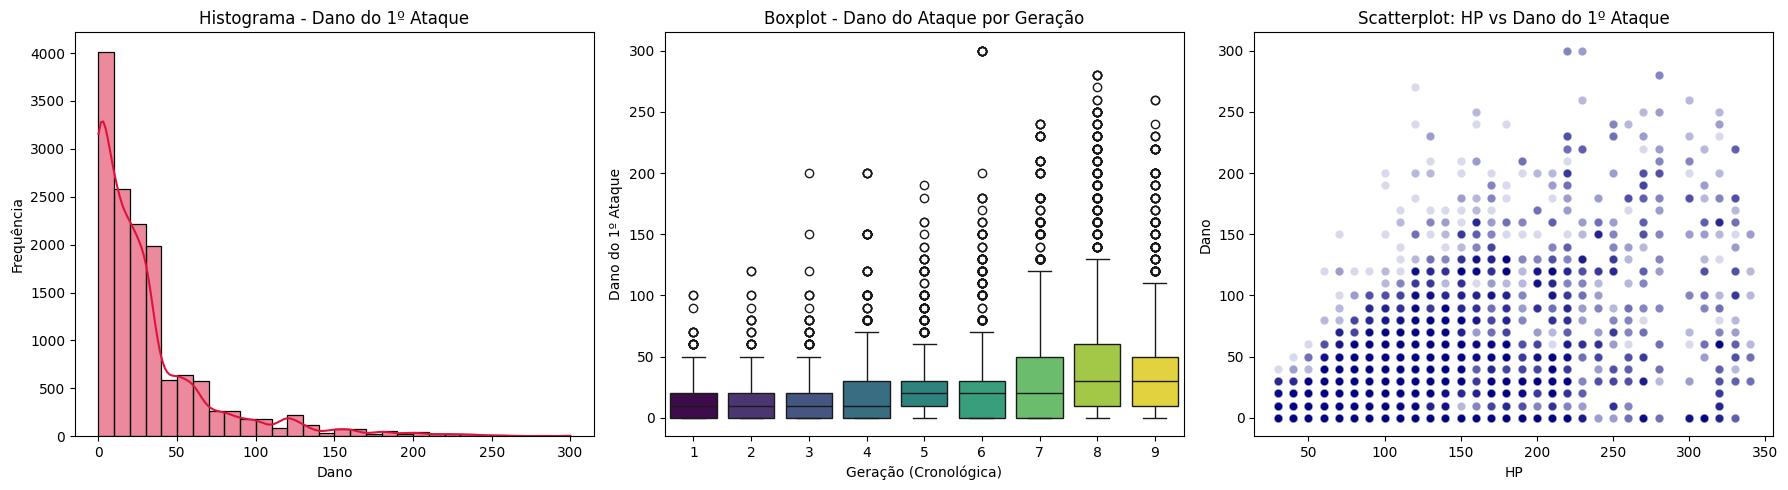

In [ ]:
# Visualizações gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma: distribuição do dano
sns.histplot(df['attack_damage'], bins=30, kde=True, color='crimson', ax=axes[0])
axes[0].set_title('Histograma - Dano do 1º Ataque')
axes[0].set_xlabel('Dano')
axes[0].set_ylabel('Frequência')

# Boxplot: dispersão de dano por geração
sns.boxplot(
    data=df,
    x='generation_encoded',
    y='attack_damage',
    hue='generation_encoded',
    palette='viridis',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Boxplot - Dano do Ataque por Geração')
axes[1].set_xlabel('Geração (Cronológica)')
axes[1].set_ylabel('Dano do 1º Ataque')

# Scatterplot: correlação HP vs dano
sns.scatterplot(data=df, x='hp', y='attack_damage', alpha=0.15, color='navy', ax=axes[2])
axes[2].set_title('Scatterplot: HP vs Dano do 1º Ataque')
axes[2].set_xlabel('HP')
axes[2].set_ylabel('Dano')

plt.tight_layout()
plt.show()

In [ ]:
# Amostragem (10% dos dados)

# Amostragem simples
amostra_simples = df.sample(frac=0.10, random_state=42)

# Amostragem estratificada (por geração)
# A função sample já resolve estratificações agrupadas em novas versões, evitando o FutureWarning:
amostra_estratificada = df.groupby('generation_encoded').sample(frac=0.10, random_state=42)

# Comparativo
print("Média de Dano de Ataque:")
print(f"População Original: {df['attack_damage'].mean():.2f}")
print(f"Amostra Simples: {amostra_simples['attack_damage'].mean():.2f}")
print(f"Amostra Estratificada: {amostra_estratificada['attack_damage'].mean():.2f}")

print("\nProporção da 1ª Geração (Base Set - Classic):")
prop_pop = (df['generation_encoded'] == 1).mean() * 100
prop_simp = (amostra_simples['generation_encoded'] == 1).mean() * 100
prop_est = (amostra_estratificada['generation_encoded'] == 1).mean() * 100
print(f"População Original: {prop_pop:.2f}%")
print(f"Amostra Simples: {prop_simp:.2f}%")
print(f"Amostra Estratificada: {prop_est:.2f}%")

Média de Dano de Ataque:
População Original: 29.55
Amostra Simples: 30.55
Amostra Estratificada: 30.47

Proporção da 1ª Geração (Base Set - Classic):
População Original: 4.13%
Amostra Simples: 4.25%
Amostra Estratificada: 4.12%
